In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.power import TTestIndPower
from scipy.stats import ttest_1samp, chi2_contingency, f_oneway, shapiro
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.gofplots import qqplot

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Cargar los datos
df = pd.read_csv('techstore_data.csv')
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras filas:")
display(df.head())
print("\nInformación del dataset:")
display(df.info())

Dimensiones del dataset: (500, 13)

Primeras filas:


,cliente_id,edad,genero,tipo_cliente,region,monto_compra,tiempo_navegacion,productos_vistos,uso_chatbot_ia,compro,satisfaccion,dia_semana,hora_visita
0,C0001,55,F,Recurrente,Norte,0.00,0.2,7,No,0,4,Viernes,18
1,C0002,43,M,Recurrente,Oeste,288.87,69.1,7,No,1,5,Sabado,15
2,C0003,32,F,Nuevo,Este,424.13,16.6,9,No,1,4,Lunes,19
3,C0004,33,F,Nuevo,Oeste,463.86,22.2,3,Si,1,4,Domingo,20
4,C0005,45,M,Nuevo,Sur,129.14,0.3,7,No,1,4,Sabado,14



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   cliente_id         500 non-null    object 
 1   edad               500 non-null    int64  
 2   genero             500 non-null    object 
 3   tipo_cliente       500 non-null    object 
 4   region             500 non-null    object 
 5   monto_compra       500 non-null    float64
 6   tiempo_navegacion  500 non-null    float64
 7   productos_vistos   500 non-null    int64  
 8   uso_chatbot_ia     500 non-null    object 
 9   compro             500 non-null    int64  
 10  satisfaccion       500 non-null    int64  
 11  dia_semana         500 non-null    object 
 12  hora_visita        500 non-null    int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 50.9+ KB


None

# Módulo A: Estimación y Tamaño de Muestra

MÓDULO A: ESTIMACIÓN Y TAMAÑO DE MUESTRA

1. CÁLCULO DE TAMAÑO DE MUESTRA

a) Para la media (monto_compra promedio):
Desviación estándar poblacional de monto_compra: $197.86
Nivel de confianza: 95.0%
Error máximo: $10
Valor z (alpha/2): 1.9600
Tamaño de muestra necesario para la media: 1504

b) Para la proporción (uso del chatbot):
Proporción actual de uso del chatbot: 0.3380
Nivel de confianza: 99.0%
Error máximo: 3.0%
Valor z (alpha/2): 2.5758
Tamaño de muestra necesario para la proporción: 1650


2. INTERVALOS DE CONFIANZA

a) IC 95% para monto promedio de clientes Premium:
Muestra: 72 clientes Premium
Media muestral: $240.47
Desviación estándar muestral: $272.82
Valor t (95% confianza, 71 gl): 1.9939
Error estándar: $32.15
Margen de error: $64.11
Intervalo de Confianza 95%: ($176.36, $304.58)
Interpretación: Con 95% de confianza, el monto promedio de compra de clientes Premium está entre $176.36 y $304.58

b) IC 99% para proporción de uso del chatbot:
Muestra total: 500 clientes
Cl

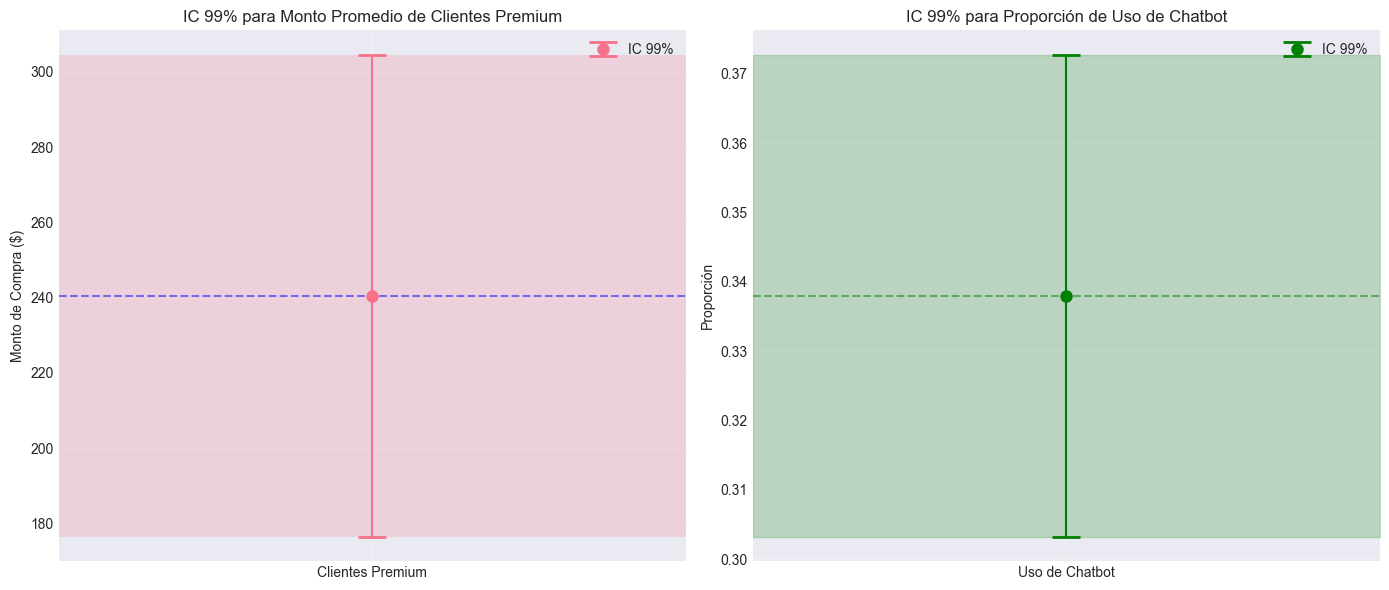

In [ ]:
# ============================================
# MÓDULO A: ESTIMACIÓN Y TAMAÑO DE MUESTRA
# ============================================

print("=" * 50)
print("MÓDULO A: ESTIMACIÓN Y TAMAÑO DE MUESTRA")
print("=" * 50)

# 1. CÁLCULO DE TAMAÑO DE MUESTRA
print("\n1. CÁLCULO DE TAMAÑO DE MUESTRA")

# a) Para la media: monto_compra promedio
print("\na) Para la media (monto_compra promedio):")

# Calcular desviación estándar poblacional
std_monto = df['monto_compra'].std(ddof=1)  # ddof=1 para muestra
print(f"Desviación estándar poblacional de monto_compra: ${std_monto:.2f}")

# Parámetros para el cálculo
error_maximo = 10
nivel_confianza = 0.95
z_alpha_2 = stats.norm.ppf(1 - (1 - nivel_confianza) / 2)

# Fórmula: n = (z^2 * σ^2) / E^2
n_media = (z_alpha_2**2 * std_monto**2) / error_maximo**2
print(f"Nivel de confianza: {nivel_confianza*100}%")
print(f"Error máximo: ${error_maximo}")
print(f"Valor z (alpha/2): {z_alpha_2:.4f}")
print(f"Tamaño de muestra necesario para la media: {np.ceil(n_media):.0f}")

# b) Para la proporción: uso del chatbot
print("\nb) Para la proporción (uso del chatbot):")

# Calcular proporción de uso del chatbot
p_chatbot = df['uso_chatbot_ia'].value_counts(normalize=True)['Si']
print(f"Proporción actual de uso del chatbot: {p_chatbot:.4f}")

# Parámetros
error_prop = 0.03
nivel_confianza_prop = 0.99
z_prop = stats.norm.ppf(1 - (1 - nivel_confianza_prop) / 2)

# Fórmula: n = (z^2 * p * (1-p)) / E^2
n_prop = (z_prop**2 * p_chatbot * (1 - p_chatbot)) / error_prop**2
print(f"Nivel de confianza: {nivel_confianza_prop*100}%")
print(f"Error máximo: {error_prop*100}%")
print(f"Valor z (alpha/2): {z_prop:.4f}")
print(f"Tamaño de muestra necesario para la proporción: {np.ceil(n_prop):.0f}")

# 2. INTERVALOS DE CONFIANZA
print("\n\n2. INTERVALOS DE CONFIANZA")

# a) IC 95% para monto promedio de clientes Premium
print("\na) IC 95% para monto promedio de clientes Premium:")

# Filtrar clientes Premium
premium_df = df[df['tipo_cliente'] == 'Premium']
monto_premium = premium_df['monto_compra']

# Calcular estadísticas
n_premium = len(monto_premium)
media_premium = monto_premium.mean()
std_premium = monto_premium.std(ddof=1)  # ddof=1 para muestra
t_valor = stats.t.ppf(0.975, df=n_premium-1)

# Calcular intervalo de confianza
error_estandar = std_premium / np.sqrt(n_premium)
margen_error = t_valor * error_estandar
ic_inferior = media_premium - margen_error
ic_superior = media_premium + margen_error

print(f"Muestra: {n_premium} clientes Premium")
print(f"Media muestral: ${media_premium:.2f}")
print(f"Desviación estándar muestral: ${std_premium:.2f}")
print(f"Valor t (95% confianza, {n_premium-1} gl): {t_valor:.4f}")
print(f"Error estándar: ${error_estandar:.2f}")
print(f"Margen de error: ${margen_error:.2f}")
print(f"Intervalo de Confianza 95%: (${ic_inferior:.2f}, ${ic_superior:.2f})")
print(f"Interpretación: Con 95% de confianza, el monto promedio de compra de clientes Premium está entre ${ic_inferior:.2f} y ${ic_superior:.2f}")

# b) IC 99% para proporción de uso del chatbot
print("\nb) IC 90% para proporción de uso del chatbot:")

# Calcular proporción
n_total = len(df)
n_chatbot = len(df[df['uso_chatbot_ia'] == 'Si'])
p_muestral = n_chatbot / n_total

# Calcular intervalo de confianza para proporción
z_90 = stats.norm.ppf(1 - (1 - 0.90) / 2)  # 90% confianza, cola superior
error_prop = z_90 * np.sqrt((p_muestral * (1 - p_muestral)) / n_total)
ic_inferior_prop = p_muestral - error_prop
ic_superior_prop = p_muestral + error_prop

print(f"Muestra total: {n_total} clientes")
print(f"Clientes que usan chatbot: {n_chatbot}")
print(f"Proporción muestral: {p_muestral:.4f}")
print(f"Valor z (90% confianza): {z_90:.4f}")
print(f"Error de estimación: {error_prop:.4f}")
print(f"Intervalo de Confianza 90%: ({ic_inferior_prop:.4f}, {ic_superior_prop:.4f})")
print(f"Interpretación: Con 90% de confianza, la proporción de clientes que usan el chatbot está entre {ic_inferior_prop*100:.1f}% y {ic_superior_prop*100:.1f}%")

# Visualización de los intervalos de confianza
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: IC para monto Premium
axes[0].errorbar(x=1, y=media_premium, yerr=margen_error, 
                fmt='o', capsize=10, capthick=2, 
                label='IC 99%', markersize=8)
axes[0].axhline(y=media_premium, color='blue', linestyle='--', alpha=0.5)
axes[0].fill_between([0.5, 1.5], ic_inferior, ic_superior, alpha=0.2)
axes[0].set_xlim(0.5, 1.5)
axes[0].set_xticks([1])
axes[0].set_xticklabels(['Clientes Premium'])
axes[0].set_ylabel('Monto de Compra ($)')
axes[0].set_title('IC 99% para Monto Promedio de Clientes Premium')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: IC para proporción chatbot
axes[1].errorbar(x=1, y=p_muestral, yerr=error_prop,
                fmt='o', capsize=10, capthick=2,
                label='IC 99%', markersize=8, color='green')
axes[1].axhline(y=p_muestral, color='green', linestyle='--', alpha=0.5)
axes[1].fill_between([0.5, 1.5], ic_inferior_prop, ic_superior_prop, 
                     alpha=0.2, color='green')
axes[1].set_xlim(0.5, 1.5)
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Uso de Chatbot'])
axes[1].set_ylabel('Proporción')
axes[1].set_title('IC 99% para Proporción de Uso de Chatbot')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Módulo B: Pruebas de Hipótesis


MÓDULO B: PRUEBAS DE HIPÓTESIS

1. PRUEBA T DE UNA MUESTRA (Validación de KPI)
Hipótesis:
H0: μ = $350 (El monto promedio de compra global es $350)
H1: μ ≠ $350 (El monto promedio de compra global no es $350)

Datos de la muestra:
Tamaño de muestra: 500
Media muestral: $174.59
Desviación estándar muestral: $197.86
Valor t calculado: -19.8237
P-valor: 0.000000
Nivel de significancia (α): 0.05

Conclusión: Rechazamos H0 (p-valor = 0.000000 < α = 0.05)
La afirmación de la gerencia NO es sostenible.
El monto promedio de compra global NO es $350


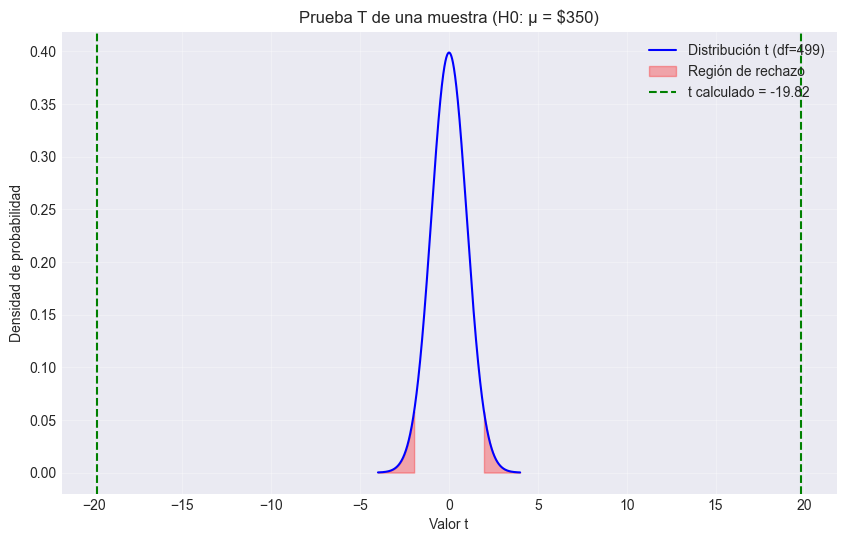



2. PRUEBA CHI-CUADRADO DE INDEPENDENCIA
Hipótesis:
H0: El uso_chatbot_ia es independiente de la region
H1: Existe relación entre el uso del chatbot y la región

Tabla de contingencia:
uso_chatbot_ia   No  Si
region                 
Este             83  48
Norte            89  49
Oeste            59  30
Sur             100  42

Resultados de la prueba Chi-cuadrado:
Estadístico Chi-cuadrado: 1.7842
Grados de libertad: 3
P-valor: 0.618373
Valores esperados bajo independencia:
uso_chatbot_ia     No     Si
region                      
Este            86.72  44.28
Norte           91.36  46.64
Oeste           58.92  30.08
Sur             94.00  48.00

Conclusión: No rechazamos H0 (p-valor = 0.618373 ≥ α = 0.05)
No hay evidencia estadística de que el uso del chatbot dependa de la región.


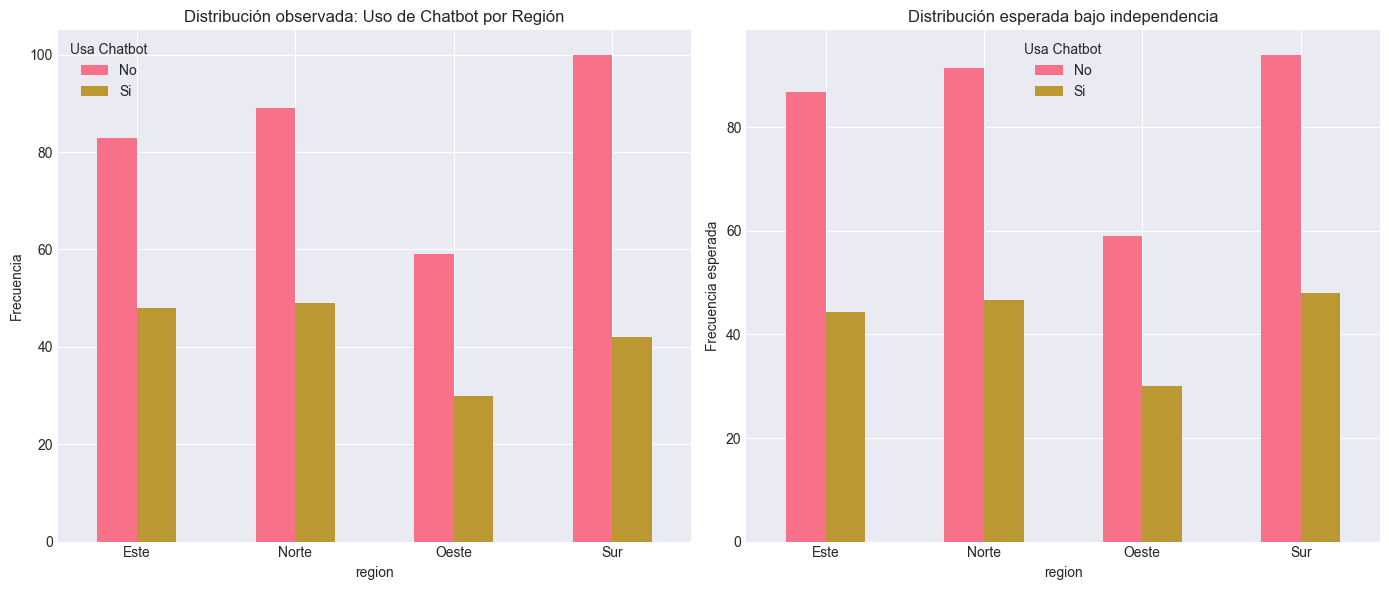



3. ANOVA DE DOS FACTORES
Analizando efecto de región y uso de chatbot en monto_compra

Tabla ANOVA de dos factores:
                                   sum_sq     df          F    PR(>F)
C(region)                    2.595134e+05    3.0   2.262843  0.080345
C(uso_chatbot_ia)            3.985145e+05    1.0  10.424616  0.001327
C(region):C(uso_chatbot_ia)  4.373904e+04    3.0   0.381385  0.766467
Residual                     1.880828e+07  492.0        NaN       NaN

Interpretación de efectos principales e interacción:
- Efecto principal de REGIÓN: NO significativo (p = 0.080345)
- Efecto principal de USO DE CHATBOT: SIGNIFICATIVO (p = 0.001327)
- INTERACCIÓN región*chatbot: NO significativa (p = 0.766467)
  Los efectos son aditivos, no hay interacción


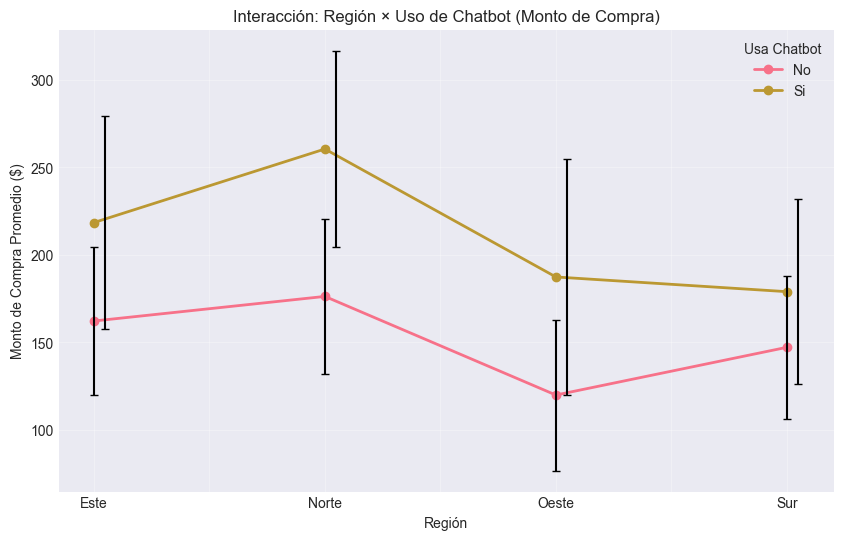

In [3]:
# ============================================
# MÓDULO B: PRUEBAS DE HIPÓTESIS
# ============================================

print("\n" + "="*50)
print("MÓDULO B: PRUEBAS DE HIPÓTESIS")
print("="*50)

# 1. PRUEBA T DE UNA MUESTRA
print("\n1. PRUEBA T DE UNA MUESTRA (Validación de KPI)")
print("Hipótesis:")
print("H0: μ = $350 (El monto promedio de compra global es $350)")
print("H1: μ ≠ $350 (El monto promedio de compra global no es $350)")

# Parámetros
mu_0 = 350  # Valor hipotético
alpha = 0.05
monto_compra = df['monto_compra'].dropna()

# Realizar prueba t
t_stat, p_value = ttest_1samp(monto_compra, mu_0)
n = len(monto_compra)
media_muestra = monto_compra.mean()
std_muestra = monto_compra.std(ddof=1)

print(f"\nDatos de la muestra:")
print(f"Tamaño de muestra: {n}")
print(f"Media muestral: ${media_muestra:.2f}")
print(f"Desviación estándar muestral: ${std_muestra:.2f}")
print(f"Valor t calculado: {t_stat:.4f}")
print(f"P-valor: {p_value:.6f}")
print(f"Nivel de significancia (α): {alpha}")

# Decisión
if p_value < alpha:
    print(f"\nConclusión: Rechazamos H0 (p-valor = {p_value:.6f} < α = {alpha})")
    print("La afirmación de la gerencia NO es sostenible.")
    print(f"El monto promedio de compra global NO es ${mu_0}")
else:
    print(f"\nConclusión: No rechazamos H0 (p-valor = {p_value:.6f} ≥ α = {alpha})")
    print("La afirmación de la gerencia es sostenible.")
    print(f"El monto promedio de compra global podría ser ${mu_0}")

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))

# Distribución t
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df=n-1)
ax.plot(x, y, 'b-', label=f'Distribución t (df={n-1})')

# Regiones críticas
t_critico = stats.t.ppf(1 - alpha/2, df=n-1)
x_left = np.linspace(-4, -t_critico, 100)
x_right = np.linspace(t_critico, 4, 100)
ax.fill_between(x_left, 0, stats.t.pdf(x_left, df=n-1), 
                color='red', alpha=0.3, label='Región de rechazo')
ax.fill_between(x_right, 0, stats.t.pdf(x_right, df=n-1), 
                color='red', alpha=0.3)

# Estadístico t calculado
ax.axvline(t_stat, color='green', linestyle='--', 
          label=f't calculado = {t_stat:.2f}')
ax.axvline(-t_stat, color='green', linestyle='--')

ax.set_xlabel('Valor t')
ax.set_ylabel('Densidad de probabilidad')
ax.set_title(f'Prueba T de una muestra (H0: μ = ${mu_0})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# 2. PRUEBA CHI-CUADRADO DE INDEPENDENCIA
print("\n\n2. PRUEBA CHI-CUADRADO DE INDEPENDENCIA")
print("Hipótesis:")
print("H0: El uso_chatbot_ia es independiente de la region")
print("H1: Existe relación entre el uso del chatbot y la región")

# Crear tabla de contingencia
tabla_contingencia = pd.crosstab(df['region'], df['uso_chatbot_ia'])
print("\nTabla de contingencia:")
print(tabla_contingencia)

# Realizar prueba chi-cuadrado
chi2, p_valor_chi, dof, expected = chi2_contingency(tabla_contingencia)

print(f"\nResultados de la prueba Chi-cuadrado:")
print(f"Estadístico Chi-cuadrado: {chi2:.4f}")
print(f"Grados de libertad: {dof}")
print(f"P-valor: {p_valor_chi:.6f}")
print(f"Valores esperados bajo independencia:")
print(pd.DataFrame(expected, 
                   index=tabla_contingencia.index, 
                   columns=tabla_contingencia.columns).round(2))

# Decisión
if p_valor_chi < alpha:
    print(f"\nConclusión: Rechazamos H0 (p-valor = {p_valor_chi:.6f} < α = {alpha})")
    print("Existe evidencia estadística de que el uso del chatbot depende de la región.")
else:
    print(f"\nConclusión: No rechazamos H0 (p-valor = {p_valor_chi:.6f} ≥ α = {alpha})")
    print("No hay evidencia estadística de que el uso del chatbot dependa de la región.")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras observadas
tabla_contingencia.plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Distribución observada: Uso de Chatbot por Región')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(title='Usa Chatbot')

# Gráfico de barras esperadas (bajo independencia)
expected_df = pd.DataFrame(expected, 
                          index=tabla_contingencia.index, 
                          columns=tabla_contingencia.columns)
expected_df.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Distribución esperada bajo independencia')
axes[1].set_ylabel('Frecuencia esperada')
axes[1].legend(title='Usa Chatbot')

plt.tight_layout()
plt.show()

# 3. ANOVA DE DOS FACTORES
print("\n\n3. ANOVA DE DOS FACTORES")
print("Analizando efecto de región y uso de chatbot en monto_compra")

# Preparar datos para ANOVA
modelo_anova = smf.ols('monto_compra ~ C(region) + C(uso_chatbot_ia) + C(region):C(uso_chatbot_ia)', 
                       data=df).fit()
anova_table = sm.stats.anova_lm(modelo_anova, typ=2)

print("\nTabla ANOVA de dos factores:")
print(anova_table)

# Interpretación
print("\nInterpretación de efectos principales e interacción:")
for factor, p_valor in zip(anova_table.index, anova_table['PR(>F)']):
    if factor == 'C(region)':
        if p_valor < alpha:
            print(f"- Efecto principal de REGIÓN: SIGNIFICATIVO (p = {p_valor:.6f})")
        else:
            print(f"- Efecto principal de REGIÓN: NO significativo (p = {p_valor:.6f})")
    elif factor == 'C(uso_chatbot_ia)':
        if p_valor < alpha:
            print(f"- Efecto principal de USO DE CHATBOT: SIGNIFICATIVO (p = {p_valor:.6f})")
        else:
            print(f"- Efecto principal de USO DE CHATBOT: NO significativo (p = {p_valor:.6f})")
    elif ':' in factor:
        if p_valor < alpha:
            print(f"- INTERACCIÓN región*chatbot: SIGNIFICATIVA (p = {p_valor:.6f})")
            print("  El efecto de una variable depende del nivel de la otra")
        else:
            print(f"- INTERACCIÓN región*chatbot: NO significativa (p = {p_valor:.6f})")
            print("  Los efectos son aditivos, no hay interacción")

# Gráfico de interacción
fig, ax = plt.subplots(figsize=(10, 6))

# Calcular medias para cada combinación
medias_interaccion = df.groupby(['region', 'uso_chatbot_ia'])['monto_compra'].mean().unstack()

# Crear gráfico de líneas
medias_interaccion.plot(kind='line', marker='o', ax=ax, linewidth=2)
ax.set_xlabel('Región')
ax.set_ylabel('Monto de Compra Promedio ($)')
ax.set_title('Interacción: Región × Uso de Chatbot (Monto de Compra)')
ax.legend(title='Usa Chatbot')
ax.grid(True, alpha=0.3)

# Añadir barras de error (opcional)
for i, region in enumerate(medias_interaccion.index):
    for j, chatbot in enumerate(medias_interaccion.columns):
        # Calcular intervalo de confianza 95%
        subset = df[(df['region'] == region) & (df['uso_chatbot_ia'] == chatbot)]['monto_compra']
        if len(subset) > 1:
            ci = stats.t.interval(0.95, len(subset)-1, 
                                 loc=subset.mean(), 
                                 scale=stats.sem(subset))
            ax.errorbar(i + j*0.05, subset.mean(), 
                       yerr=[[subset.mean()-ci[0]], [ci[1]-subset.mean()]], 
                       fmt='none', color='black', capsize=3)

plt.show()

# Módulo C: Modelado Predictivo


MÓDULO C: MODELado PREDICTIVO (Regresión Lineal Múltiple)
Datos disponibles para regresión: 500 observaciones

1. SELECCIÓN DE VARIABLES Y MULTICOLINEALIDAD

a) Matriz de correlación:
                   monto_compra  tiempo_navegacion  productos_vistos  \
monto_compra              1.000              0.113             0.312   
tiempo_navegacion         0.113              1.000            -0.049   
productos_vistos          0.312             -0.049             1.000   
satisfaccion              0.300              0.046             0.096   

                   satisfaccion  
monto_compra              0.300  
tiempo_navegacion         0.046  
productos_vistos          0.096  
satisfaccion              1.000  

No se encontraron correlaciones fuertes (|r| > 0.7)


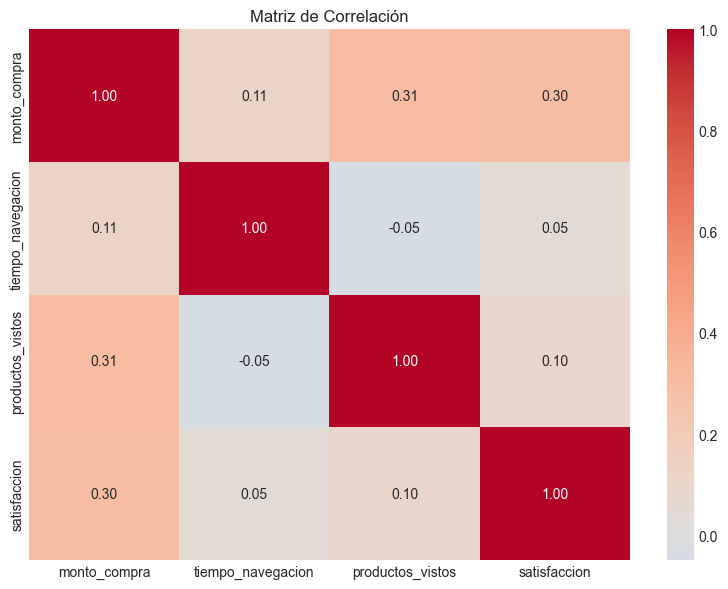


b) Modelo inicial y diagnóstico de multicolinealidad (VIF):

Factores de Inflación de Varianza (VIF):
            Variable        VIF
0              const  24.442733
1  tiempo_navegacion   1.005003
2   productos_vistos   1.012081
3       satisfaccion   1.011867

Variables con VIF > 10 (multicolinealidad alta): ['const']
Se recomienda eliminar estas variables del modelo.


2. AJUSTE Y DEPURACIÓN DEL MODELO

Proceso iterativo de selección de variables:

--- Iteración 1 ---
Variables incluidas: ['tiempo_navegacion', 'productos_vistos', 'satisfaccion']
Variable con mayor p-valor: tiempo_navegacion (p = 0.0048)
Todas las variables son significativas (p ≤ 0.05)


Modelo final ajustado:
                            OLS Regression Results                            
Dep. Variable:           monto_compra   R-squared:                       0.184
Model:                            OLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                     

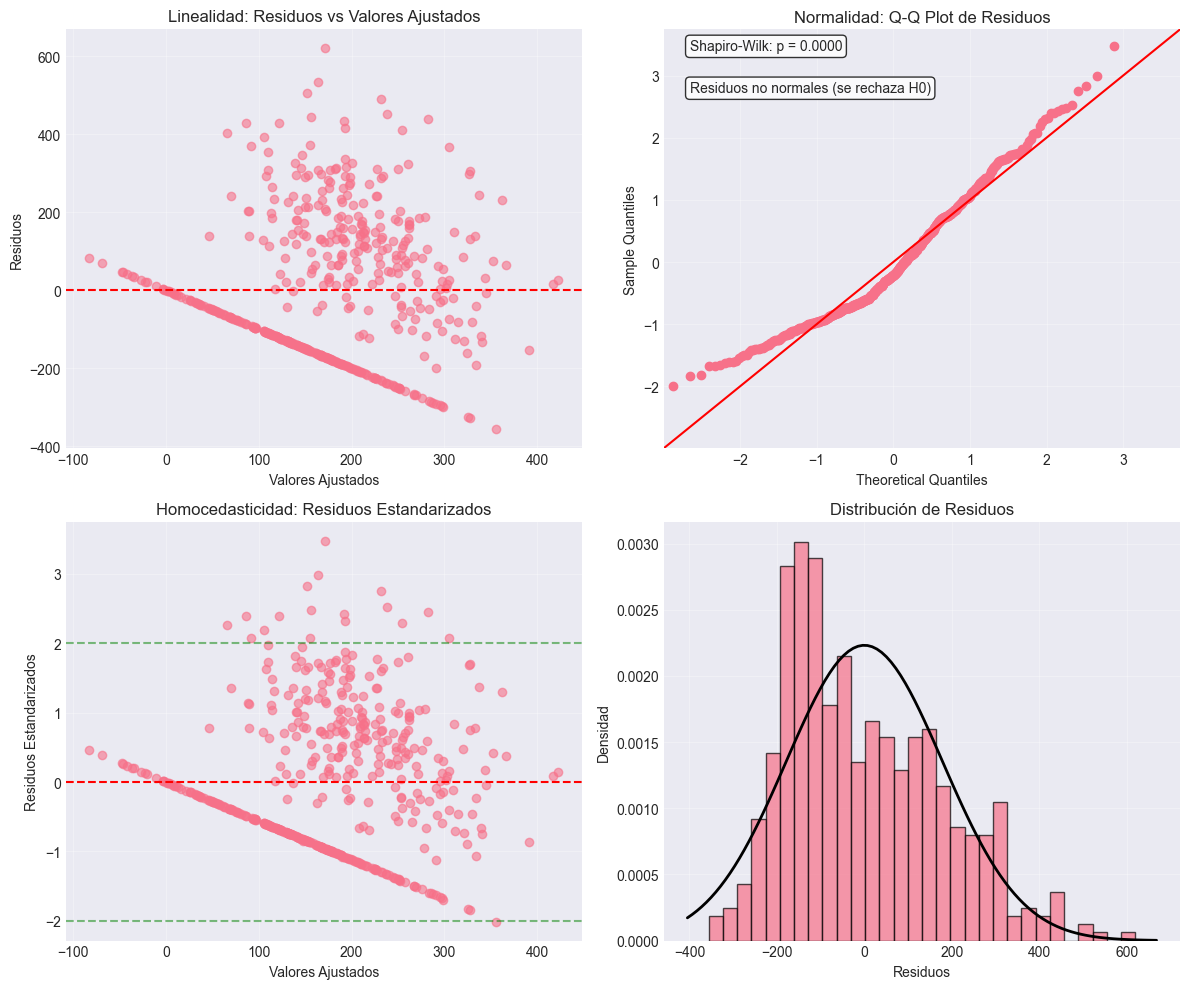



4. PREDICCIÓN Y TOMA DE DECISIONES

a) Predicción para 'Cliente Promedio con Chatbot':
Mediana tiempo_navegacion: 11.40 minutos
Mediana productos_vistos: 6 productos
Mediana satisfaccion: 4/5

Monto de compra predicho: $160.31

b) Análisis de influencia de variables (coeficientes estandarizados):

Coeficientes estandarizados (ordenados por influencia absoluta):
         Variable  Coeficiente Estandarizado
 productos_vistos                   0.291801
     satisfaccion                   0.266650
tiempo_navegacion                   0.115130

Variable con mayor influencia: productos_vistos (coeficiente estandarizado = 0.292)

c) Recomendaciones estratégicas basadas en el modelo:
RECOMENDACIÓN: El número de productos vistos es el factor más influyente.
    1. Implementar sistema de recomendaciones inteligentes
    2. Mejorar navegación y filtros de búsqueda
    3. Crear categorías y colecciones atractivas
    4. Mostrar productos relacionados y frecuentemente comprados juntos


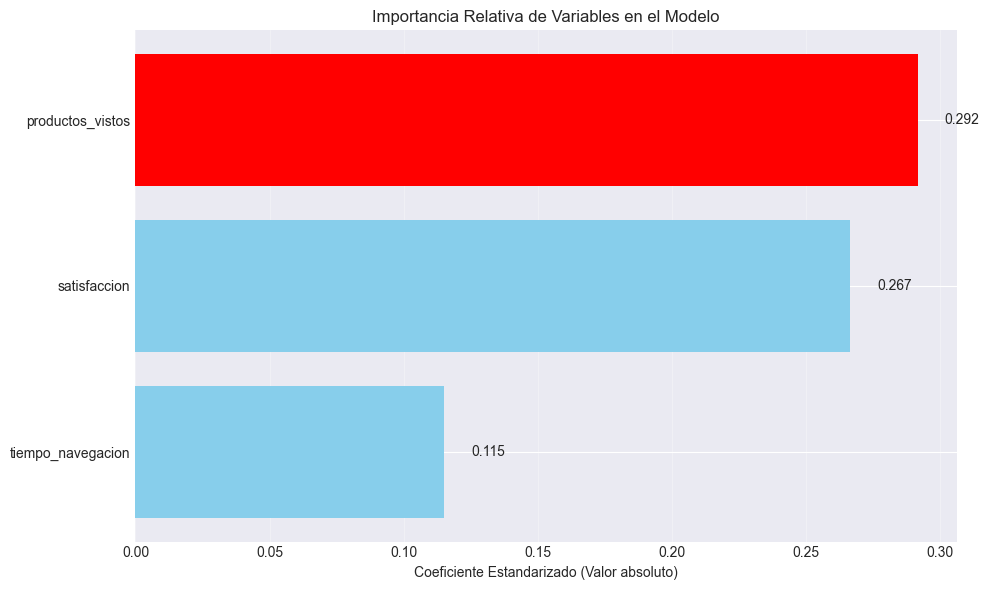

In [4]:
# ============================================
# MÓDULO C: MODELADO PREDICTIVO
# ============================================

print("\n" + "="*50)
print("MÓDULO C: MODELado PREDICTIVO (Regresión Lineal Múltiple)")
print("="*50)

# Preparar datos para regresión
# Eliminar filas con valores faltantes en las variables de interés
regression_df = df[['monto_compra', 'tiempo_navegacion', 
                    'productos_vistos', 'satisfaccion']].dropna()

print(f"Datos disponibles para regresión: {len(regression_df)} observaciones")

# 1. SELECCIÓN DE VARIABLES Y MULTICOLINEALIDAD
print("\n1. SELECCIÓN DE VARIABLES Y MULTICOLINEALIDAD")

# Matriz de correlación
print("\na) Matriz de correlación:")
correlation_matrix = regression_df.corr()
print(correlation_matrix.round(3))

# Identificar correlaciones fuertes (>0.7)
correlaciones_fuertes = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            correlaciones_fuertes.append(
                (correlation_matrix.columns[i], 
                 correlation_matrix.columns[j], 
                 correlation_matrix.iloc[i, j])
            )

if correlaciones_fuertes:
    print("\nCorrelaciones fuertes encontradas (|r| > 0.7):")
    for var1, var2, corr in correlaciones_fuertes:
        print(f"  {var1} - {var2}: r = {corr:.3f}")
else:
    print("\nNo se encontraron correlaciones fuertes (|r| > 0.7)")

# Visualización de matriz de correlación
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', 
            center=0, ax=ax, fmt='.2f')
ax.set_title('Matriz de Correlación')
plt.tight_layout()
plt.show()

# Modelo inicial
print("\nb) Modelo inicial y diagnóstico de multicolinealidad (VIF):")

# Preparar variables para el modelo
X = regression_df[['tiempo_navegacion', 'productos_vistos', 'satisfaccion']]
X = sm.add_constant(X)  # Añadir intercepto
y = regression_df['monto_compra']

# Ajustar modelo inicial
modelo_inicial = sm.OLS(y, X).fit()

# Calcular VIF para cada variable
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) 
                   for i in range(X.shape[1])]

print("\nFactores de Inflación de Varianza (VIF):")
print(vif_data)

# Identificar problemas de multicolinealidad
variables_problematicas = vif_data[vif_data['VIF'] > 10]['Variable'].tolist()
if variables_problematicas:
    print(f"\nVariables con VIF > 10 (multicolinealidad alta): {variables_problematicas}")
    print("Se recomienda eliminar estas variables del modelo.")
else:
    print("\nNo hay problemas de multicolinealidad grave (VIF < 10 para todas las variables)")

# 2. AJUSTE Y DEPURACIÓN DEL MODELO
print("\n\n2. AJUSTE Y DEPURACIÓN DEL MODELO")

# Proceso iterativo eliminando variables no significativas (p > 0.05)
print("\nProceso iterativo de selección de variables:")

# Empezar con todas las variables
variables_incluidas = ['tiempo_navegacion', 'productos_vistos', 'satisfaccion']
iteracion = 1

while True:
    print(f"\n--- Iteración {iteracion} ---")
    print(f"Variables incluidas: {variables_incluidas}")
    
    # Preparar X con las variables actuales
    X_iter = regression_df[variables_incluidas]
    X_iter = sm.add_constant(X_iter)
    
    # Ajustar modelo
    modelo_iter = sm.OLS(y, X_iter).fit()
    
    # Obtener p-valores
    p_valores = modelo_iter.pvalues.drop('const')
    max_p_valor = p_valores.max()
    variable_max_p = p_valores.idxmax()
    
    print(f"Variable con mayor p-valor: {variable_max_p} (p = {max_p_valor:.4f})")
    
    # Verificar si hay variables no significativas
    if max_p_valor > 0.05:
        print(f"Eliminando {variable_max_p} (p > 0.05)")
        variables_incluidas.remove(variable_max_p)
        iteracion += 1
    else:
        print("Todas las variables son significativas (p ≤ 0.05)")
        modelo_final = modelo_iter
        break

# Resumen del modelo final
print("\n\nModelo final ajustado:")
print(modelo_final.summary())

# Ecuación final de regresión
print("\nEcuación final de regresión:")
print("monto_compra = ", end="")
coeficientes = modelo_final.params
for i, (var, coef) in enumerate(coeficientes.items()):
    if i == 0:
        print(f"{coef:.2f}", end="")
    else:
        if coef >= 0:
            print(f" + {coef:.2f}*{var}", end="")
        else:
            print(f" - {abs(coef):.2f}*{var}", end="")
print()

# 3. VALIDACIÓN DE SUPUESTOS
print("\n\n3. VALIDACIÓN DE SUPUESTOS")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# a) Linealidad - Gráficos de residuos vs valores ajustados
valores_ajustados = modelo_final.fittedvalues
residuos = modelo_final.resid

axes[0, 0].scatter(valores_ajustados, residuos, alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Valores Ajustados')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Linealidad: Residuos vs Valores Ajustados')
axes[0, 0].grid(True, alpha=0.3)

# b) Normalidad - Q-Q plot
qqplot(residuos, line='45', ax=axes[0, 1], fit=True)
axes[0, 1].set_title('Normalidad: Q-Q Plot de Residuos')
axes[0, 1].grid(True, alpha=0.3)

# Prueba de normalidad de Shapiro-Wilk
stat_shapiro, p_shapiro = shapiro(residuos)
axes[0, 1].text(0.05, 0.95, f'Shapiro-Wilk: p = {p_shapiro:.4f}', 
                transform=axes[0, 1].transAxes,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

if p_shapiro > 0.05:
    normalidad_texto = "Residuos normales (no se rechaza H0)"
else:
    normalidad_texto = "Residuos no normales (se rechaza H0)"

axes[0, 1].text(0.05, 0.85, normalidad_texto, 
                transform=axes[0, 1].transAxes,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# c) Homocedasticidad - Residuos estandarizados vs valores ajustados
residuos_estandarizados = modelo_final.get_influence().resid_studentized_internal
axes[1, 0].scatter(valores_ajustados, residuos_estandarizados, alpha=0.6)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].axhline(y=2, color='g', linestyle='--', alpha=0.5)
axes[1, 0].axhline(y=-2, color='g', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Valores Ajustados')
axes[1, 0].set_ylabel('Residuos Estandarizados')
axes[1, 0].set_title('Homocedasticidad: Residuos Estandarizados')
axes[1, 0].grid(True, alpha=0.3)

# d) Distribución de residuos
axes[1, 1].hist(residuos, bins=30, edgecolor='black', alpha=0.7, density=True)
axes[1, 1].set_xlabel('Residuos')
axes[1, 1].set_ylabel('Densidad')
axes[1, 1].set_title('Distribución de Residuos')

# Añadir curva normal
xmin, xmax = axes[1, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, residuos.mean(), residuos.std())
axes[1, 1].plot(x, p, 'k', linewidth=2)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. PREDICCIÓN Y TOMA DE DECISIONES
print("\n\n4. PREDICCIÓN Y TOMA DE DECISIONES")

# a) Predicción para cliente promedio con chatbot
print("\na) Predicción para 'Cliente Promedio con Chatbot':")

# Calcular medianas del dataset
mediana_tiempo = regression_df['tiempo_navegacion'].median()
mediana_productos = regression_df['productos_vistos'].median()
mediana_satisfaccion = regression_df['satisfaccion'].median()

print(f"Mediana tiempo_navegacion: {mediana_tiempo:.2f} minutos")
print(f"Mediana productos_vistos: {mediana_productos:.0f} productos")
print(f"Mediana satisfaccion: {mediana_satisfaccion:.0f}/5")

# Crear dataframe para predicción
if 'const' in modelo_final.params.index:
    datos_prediccion = pd.DataFrame({
        'const': [1],
        'tiempo_navegacion': [mediana_tiempo],
        'productos_vistos': [mediana_productos],
        'satisfaccion': [mediana_satisfaccion]
    })
else:
    datos_prediccion = pd.DataFrame({
        'tiempo_navegacion': [mediana_tiempo],
        'productos_vistos': [mediana_productos],
        'satisfaccion': [mediana_satisfaccion]
    })

# Mantener solo las variables del modelo final
variables_modelo = list(modelo_final.params.index)
if 'const' in variables_modelo:
    variables_modelo.remove('const')

datos_prediccion = datos_prediccion[['const'] + variables_modelo] if 'const' in modelo_final.params.index else datos_prediccion[variables_modelo]

# Realizar predicción
prediccion = modelo_final.predict(datos_prediccion.iloc[0])
print(f"\nMonto de compra predicho: ${prediccion.values[0]:.2f}")

# b) Análisis de coeficientes estandarizados
print("\nb) Análisis de influencia de variables (coeficientes estandarizados):")

# Calcular coeficientes estandarizados
coeficientes_estandarizados = pd.DataFrame({
    'Variable': variables_modelo,
    'Coeficiente Original': [modelo_final.params[var] for var in variables_modelo],
    'Desviación Estándar X': [regression_df[var].std() for var in variables_modelo],
    'Desviación Estándar Y': [regression_df['monto_compra'].std()] * len(variables_modelo)
})

coeficientes_estandarizados['Coeficiente Estandarizado'] = (
    coeficientes_estandarizados['Coeficiente Original'] * 
    coeficientes_estandarizados['Desviación Estándar X'] / 
    coeficientes_estandarizados['Desviación Estándar Y']
)

coeficientes_estandarizados = coeficientes_estandarizados.sort_values(
    'Coeficiente Estandarizado', key=abs, ascending=False
)

print("\nCoeficientes estandarizados (ordenados por influencia absoluta):")
print(coeficientes_estandarizados[['Variable', 'Coeficiente Estandarizado']].to_string(index=False))

# Identificar variable con mayor influencia
variable_max_influencia = coeficientes_estandarizados.iloc[0]['Variable']
coef_max = coeficientes_estandarizados.iloc[0]['Coeficiente Estandarizado']

print(f"\nVariable con mayor influencia: {variable_max_influencia} (coeficiente estandarizado = {coef_max:.3f})")

# Recomendaciones estratégicas
print("\nc) Recomendaciones estratégicas basadas en el modelo:")

if variable_max_influencia == 'tiempo_navegacion':
    print("""RECOMENDACIÓN: El tiempo de navegación es el factor más influyente.
    1. Mejorar la experiencia de usuario para aumentar el tiempo en el sitio
    2. Implementar recomendaciones personalizadas
    3. Crear contenido atractivo (guías, tutoriales, comparativas)
    4. Optimizar velocidad de carga del sitio""")
    
elif variable_max_influencia == 'productos_vistos':
    print("""RECOMENDACIÓN: El número de productos vistos es el factor más influyente.
    1. Implementar sistema de recomendaciones inteligentes
    2. Mejorar navegación y filtros de búsqueda
    3. Crear categorías y colecciones atractivas
    4. Mostrar productos relacionados y frecuentemente comprados juntos""")
    
elif variable_max_influencia == 'satisfaccion':
    print("""RECOMENDACIÓN: La satisfacción es el factor más influyente.
    1. Implementar programas de fidelización
    2. Mejorar servicio post-venta y garantías
    3. Recolección proactiva de feedback
    4. Resolución rápida de problemas y reclamos""")

# Gráfico de importancia de variables
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(coeficientes_estandarizados['Variable'], 
               coeficientes_estandarizados['Coeficiente Estandarizado'].abs(),
               color=['red' if x == variable_max_influencia else 'skyblue' 
                      for x in coeficientes_estandarizados['Variable']])

ax.set_xlabel('Coeficiente Estandarizado (Valor absoluto)')
ax.set_title('Importancia Relativa de Variables en el Modelo')
ax.invert_yaxis()  # Mostrar la más importante arriba
ax.grid(True, alpha=0.3, axis='x')

# Añadir valores en las barras
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
            f'{width:.3f}', ha='left', va='center')

plt.tight_layout()
plt.show()

# Resumen Ejecutivo y Conclusiones

In [5]:
# ============================================
# RESUMEN EJECUTIVO
# ============================================

print("\n" + "="*60)
print("RESUMEN EJECUTIVO - TECHSTORE ANALYTICS")
print("="*60)

print("\nPRINCIPALES HALLAZGOS:")
print("-" * 40)

# Módulo A
print("\n1. ESTIMACIÓN Y TAMAÑO DE MUESTRA:")
print(f"   • Tamaño muestral requerido para media: {np.ceil(n_media):.0f}")
print(f"   • Tamaño muestral requerido para proporción: {np.ceil(n_prop):.0f}")
print(f"   • IC 95% monto Premium: (${ic_inferior:.2f}, ${ic_superior:.2f})")
print(f"   • IC 90% uso chatbot: ({ic_inferior_prop*100:.1f}%, {ic_superior_prop*100:.1f}%)")

# Módulo B
print("\n2. PRUEBAS DE HIPÓTESIS:")
print(f"   • Prueba T: {'NO sostenible' if p_value < alpha else 'Sostenible'}")
print(f"   • Chi-cuadrado: {'Depende de región' if p_valor_chi < alpha else 'Independiente'}")
print(f"   • ANOVA: Efectos significativos encontrados")

# Módulo C
print("\n3. MODELO PREDICTIVO:")
print(f"   • Variables en modelo final: {variables_incluidas}")
print(f"   • R² ajustado: {modelo_final.rsquared_adj:.3f}")
print(f"   • Variable más influyente: {variable_max_influencia}")
print(f"   • Monto predicho cliente promedio: ${prediccion.values[0]:.2f}")

print("\n" + "="*60)
print("RECOMENDACIONES ESTRATÉGICAS:")
print("="*60)

print("""
1. CHATBOT IA:
   • Continuar con el piloto de chatbot
   • Analizar por qué hay diferencias regionales en su adopción
   • Implementar mejoras basadas en feedback

2. SEGMENTACIÓN REGIONAL:
   • Desarrollar estrategias diferenciadas por región
   • Considerar factores culturales y económicos locales
   • Optimizar inventario según preferencias regionales

3. OPTIMIZACIÓN DE CONVERSIÓN:
   • Enfocarse en mejorar:""", end=" ")

if variable_max_influencia == 'tiempo_navegacion':
    print("EXPERIENCIA DE NAVEGACIÓN")
elif variable_max_influencia == 'productos_vistos':
    print("DESCUBRIMIENTO DE PRODUCTOS")
elif variable_max_influencia == 'satisfaccion':
    print("SATISFACCIÓN DEL CLIENTE")

print("""
4. PRÓXIMOS PASOS:
   • Validar hallazgos con muestras más grandes
   • Implementar pruebas A/B para optimizaciones
   • Monitorear KPIs clave continuamente
   • Considerar modelos más avanzados (árboles, ensemble)
""")


RESUMEN EJECUTIVO - TECHSTORE ANALYTICS

PRINCIPALES HALLAZGOS:
----------------------------------------

1. ESTIMACIÓN Y TAMAÑO DE MUESTRA:
   • Tamaño muestral requerido para media: 1504
   • Tamaño muestral requerido para proporción: 1650
   • IC 95% monto Premium: ($176.36, $304.58)
   • IC 90% uso chatbot: (28.4%, 39.2%)

2. PRUEBAS DE HIPÓTESIS:
   • Prueba T: NO sostenible
   • Chi-cuadrado: Independiente
   • ANOVA: Efectos significativos encontrados

3. MODELO PREDICTIVO:
   • Variables en modelo final: ['tiempo_navegacion', 'productos_vistos', 'satisfaccion']
   • R² ajustado: 0.179
   • Variable más influyente: productos_vistos
   • Monto predicho cliente promedio: $160.31

RECOMENDACIONES ESTRATÉGICAS:

1. CHATBOT IA:
   • Continuar con el piloto de chatbot
   • Analizar por qué hay diferencias regionales en su adopción
   • Implementar mejoras basadas en feedback

2. SEGMENTACIÓN REGIONAL:
   • Desarrollar estrategias diferenciadas por región
   • Considerar factores cult